In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import pandas as pd


# # IMPORTANT: Replace 'your_input_file.txt' with the actual path to your .txt file.
# txt_file_path = 'E:\Data science Studies\engine-predictive-maintenance\sensor.txt'

# # IMPORTANT: Replace 'your_output_file.csv' with the desired path for your .csv file.
# csv_file_path = 'E:\Data science Studies\engine-predictive-maintenance\sensor.csv'

# # Set the delimiter for your .txt file. Common delimiters:
# # ',', '\t' (for tab), '\s+' (for one or more spaces), ';' (for semicolon)
# # If your .txt file has no specific separator (e.g., fixed-width columns), 
# # you might need to use `pd.read_fwf` instead of `pd.read_csv`.
# delimiter = ','

# # --- Conversion logic ---
# try:
#     # Read the .txt file into a pandas DataFrame
#     df = pd.read_csv(txt_file_path, sep=delimiter)
    
#     # Write the DataFrame to a .csv file
#     df.to_csv(csv_file_path, index=False)
    
#     print(f"Successfully converted '{txt_file_path}' to '{csv_file_path}'")
#     print("First 5 rows of the converted CSV data:")
#     display(df.head())
    
# except FileNotFoundError:
#     print(f"Error: The file '{txt_file_path}' was not found. Please check the path.")
# except Exception as e:
#     print(f"An error occurred during conversion: {e}")

In [3]:
sensor_data = pd.read_csv('sensor.csv')
print(sensor_data)

            ID  sensor_00  sensor_01  sensor_02  sensor_03   sensor_04  \
0            1   2.465394   47.09201  53.211800  46.310760  634.375000   
1            2   2.465394   47.09201  53.211800  46.310760  634.375000   
2            3   2.444734   47.35243  53.211800  46.397570  638.888900   
3            4   2.460474   47.09201  53.168400  46.397568  628.125000   
4            5   2.445718   47.13541  53.211800  46.397568  636.458300   
...        ...        ...        ...        ...        ...         ...   
220308  220309   2.407350   47.69965  50.520830  43.142361  634.722229   
220309  220310   2.400463   47.69965  50.564240  43.142361  630.902771   
220310  220311   2.396528   47.69965  50.520830  43.142361  625.925903   
220311  220312   2.406366   47.69965  50.520832  43.142361  635.648100   
220312  220313   2.396528   47.69965  50.520832  43.142361  639.814800   

        sensor_05  sensor_06  sensor_07  sensor_08  ...  sensor_43  sensor_44  \
0        76.45975   13.41146  

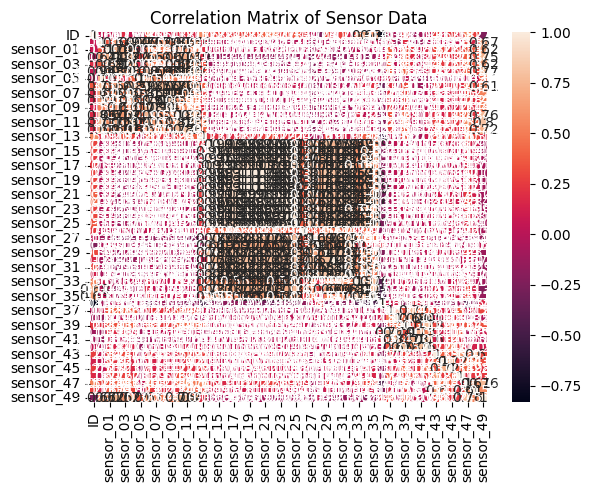

In [4]:
corr_matrix = sensor_data.iloc[:, 0:51].corr()

sns.heatmap(corr_matrix, annot=True)
plt.rcParams['figure.figsize'] = [15, 15]
plt.title('Correlation Matrix of Sensor Data')
plt.show()

In [5]:
counter = 0
for i in range(0, 51):
    for j in range(i + 1, 51):
        if((corr_matrix.iloc[i, j] > 0.7) | (corr_matrix.iloc[i, j] < -0.7)):
            print(counter , i, j, corr_matrix.iloc[i, j])
            counter = counter + 1
            

0 0 37 -0.8291001542058636
1 1 5 0.9428999055250306
2 1 6 0.7566563857417025
3 1 7 0.7507366009055012
4 1 11 0.8614480538551018
5 1 12 0.7707212978326299
6 2 3 0.7374064455579192
7 3 4 0.8223386790391445
8 3 5 0.8203922430541137
9 3 11 0.7565898212621941
10 3 12 0.7113326110198461
11 3 50 0.7490863253372084
12 5 7 0.8038762796092045
13 5 11 0.9075540328705785
14 5 12 0.862637161130918
15 5 13 0.8031656382863029
16 5 50 0.7738396713474919
17 7 8 0.8530357884776147
18 7 9 0.7640213710291174
19 7 10 0.7750287392354733
20 7 11 0.7609655848777878
21 7 12 0.7547649167138246
22 8 9 0.9067178677096641
23 8 10 0.9028351433443043
24 9 10 0.8448857330079766
25 11 12 0.8258940911552941
26 11 13 0.7663216331772968
27 11 50 0.7606816178775552
28 12 13 0.8317067001508044
29 12 50 0.8005653676570874
30 13 50 0.7247684727401991
31 15 16 0.9903591662548819
32 15 17 0.9301880155564075
33 15 18 0.9011021448087404
34 15 19 0.983040304147985
35 15 20 0.9799840382673692
36 15 21 0.9717043612300369
37 15 22 0

In [7]:
normal_data = sensor_data.loc[sensor_data["machine_status"]== "NORMAL"]
broken_data = sensor_data.loc[sensor_data["machine_status"]== "BROKEN"]
recovering_data = sensor_data.loc[sensor_data["machine_status"]== "RECOVERING"]

print(len(normal_data), len(recovering_data), len(broken_data))

0 0 0
